In [1]:
import os
import gzip
import pickle
import numpy as np
import librosa
from sklearn.decomposition import NMF
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings('ignore')

Starting comprehensive n_components analysis...
Testing range: 1 to 8
Analyzing n_components from 1 to 8
Processing 150 songs...


Processing songs:   8%|▊         | 12/150 [01:25<14:42,  6.40s/it]

Audio file not found for song 20


Processing songs: 100%|██████████| 150/150 [13:46<00:00,  5.51s/it]


Successfully processed 149 songs


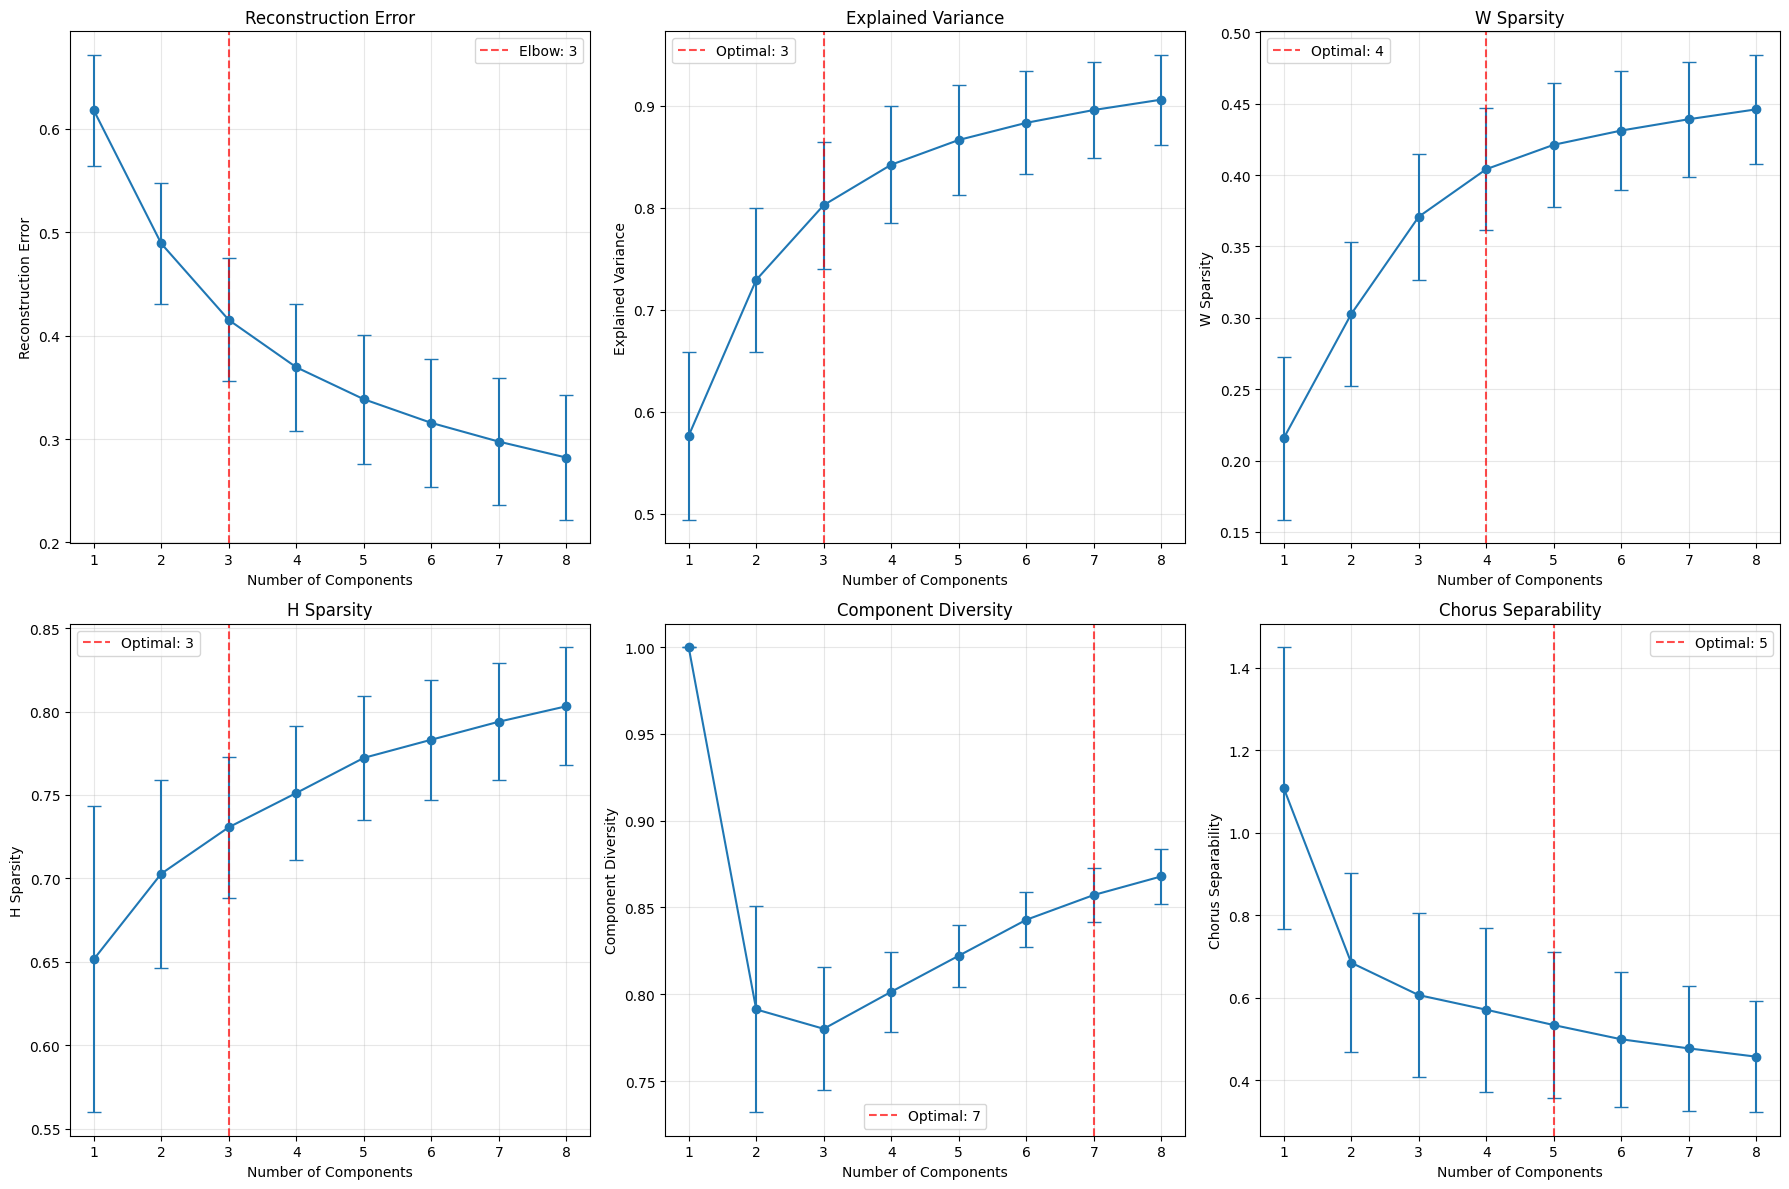


OPTIMAL N_COMPONENTS RECOMMENDATIONS
reconstruction_errors    :  3 components (weight: 0.30)
explained_variances      :  3 components (weight: 0.20)
chorus_separabilities    :  5 components (weight: 0.30)
diversities              :  7 components (weight: 0.15)
h_sparsities             :  3 components (weight: 0.05)
------------------------------------------------------------
WEIGHTED RECOMMENDATION: 4 components
------------------------------------------------------------
Conservative recommendation: 3 components

CONSIDERATIONS:
- Lower values (3-8) for computational efficiency
- Higher values (8-15) for complex musical arrangements
- Consider your dataset size and computational resources
- Test the top 2-3 candidates with your full pipeline

Results saved to: ../results/component_analysis


In [ ]:
class ComponentOptimizer:
    """
    Systematic investigation of optimal n_components for NMF decomposition
    of spectrograms for chorus detection
    """

    def __init__(self, audio_dir, csv_file, sr=12000, hop_length=128, n_mels=128, n_fft=2048, spectrogram_type='linear', freq_mask=None):
        self.audio_dir = audio_dir
        self.csv_file = csv_file
        self.sr = sr
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.n_fft = n_fft  # Add this missing parameter
        self.spectrogram_type = spectrogram_type  # Add this missing parameter
        self.freq_mask = freq_mask  # Add this missing parameter
        self.df = pd.read_csv(csv_file)
        
        # Results storage
        self.reconstruction_errors = {}
        self.explained_variance = {}
        self.sparsity_metrics = {}
        self.component_diversity = {}
        self.chorus_separability = {}
        
    def extract_spectrogram(self, audio_file):
        """Extract regular spectrogram from audio file"""
        try:
            y, sr = librosa.load(audio_file, sr=self.sr)
            
            # Compute STFT
            stft = librosa.stft(y, n_fft=self.n_fft, hop_length=self.hop_length)
            magnitude = np.abs(stft)
            
            # Apply frequency range filtering if specified
            if self.freq_mask is not None:
                magnitude = magnitude[self.freq_mask, :]
            
            # Apply scaling based on spectrogram_type
            if self.spectrogram_type == 'log':
                # Convert to log scale (dB)
                magnitude = librosa.amplitude_to_db(magnitude, ref=np.max)
                # Normalize
                normalized_spec = (magnitude - magnitude.mean()) / (magnitude.std() + 1e-6)
                # Ensure non-negative for NMF
                positive_spec = normalized_spec - normalized_spec.min() + 1e-6
            elif self.spectrogram_type == 'power':
                # Convert to power spectrogram
                power_spec = magnitude ** 2
                # Convert to dB
                power_spec_db = librosa.power_to_db(power_spec, ref=np.max)
                # Normalize
                normalized_spec = (power_spec_db - power_spec_db.mean()) / (power_spec_db.std() + 1e-6)
                # Ensure non-negative for NMF
                positive_spec = normalized_spec - normalized_spec.min() + 1e-6
            else:  # linear
                # Use linear magnitude directly
                # Normalize
                normalized_spec = (magnitude - magnitude.mean()) / (magnitude.std() + 1e-6)
                # Ensure non-negative for NMF (magnitude is already non-negative)
                positive_spec = normalized_spec - normalized_spec.min() + 1e-6
            
            return positive_spec.T  # Time x Frequency
            
        except Exception as e:
            print(f"Error processing {audio_file}: {e}")
            return None
    
    def get_chorus_labels(self, song_id, n_frames):
        """Get chorus labels for a song"""
        song_data = self.df[self.df['song_id'] == song_id]
        labels = np.zeros(n_frames, dtype=bool)
        
        for _, row in song_data.iterrows():
            if row['label'] == 'chorus':
                start_frame = int(row['start_frame'])
                end_frame = int(row['end_frame'])
                if end_frame <= n_frames:
                    labels[start_frame:end_frame] = True
        
        return labels
    
    def compute_reconstruction_error(self, X, n_components_range):
        """Compute reconstruction error for different n_components"""
        errors = []
        
        for n_comp in n_components_range:
            model = NMF(
                n_components=n_comp, 
                init='nndsvda', 
                random_state=42,
                max_iter=500,
                l1_ratio=0.8
            )
            W = model.fit_transform(X)
            H = model.components_
            X_reconstructed = W @ H
            
            # Reconstruction error (Frobenius norm)
            error = np.linalg.norm(X - X_reconstructed, 'fro') / np.linalg.norm(X, 'fro')
            errors.append(error)
            
        return errors
    
    def compute_explained_variance(self, X, n_components_range):
        """Compute explained variance ratio for different n_components"""
        variances = []
        total_variance = np.var(X)
        
        for n_comp in n_components_range:
            model = NMF(
                n_components=n_comp,
                init='nndsvda',
                random_state=42,
                max_iter=500,
                l1_ratio=0.8
            )
            W = model.fit_transform(X)
            H = model.components_
            X_reconstructed = W @ H
            
            explained_var = 1 - (np.var(X - X_reconstructed) / total_variance)
            variances.append(explained_var)
            
        return variances
    
    def compute_sparsity(self, W, H):
        """Compute sparsity metrics for NMF components"""
        # Hoyer sparsity for W and H
        def hoyer_sparsity(x):
            n = len(x.flatten())
            return (np.sqrt(n) - np.sum(np.abs(x)) / np.sqrt(np.sum(x**2))) / (np.sqrt(n) - 1)
        
        w_sparsity = hoyer_sparsity(W)
        h_sparsity = hoyer_sparsity(H)
        
        return w_sparsity, h_sparsity
    
    def compute_component_diversity(self, H):
        """Compute diversity between components"""
        # Cosine similarity between components
        similarities = []
        n_comp = H.shape[0]
        
        for i in range(n_comp):
            for j in range(i+1, n_comp):
                sim = np.dot(H[i], H[j]) / (np.linalg.norm(H[i]) * np.linalg.norm(H[j]))
                similarities.append(sim)
        
        # Diversity is inverse of mean similarity
        mean_similarity = np.mean(similarities) if similarities else 0
        diversity = 1 - mean_similarity
        
        return diversity
    
    def compute_chorus_separability(self, W, chorus_labels):
        """Compute how well components separate chorus from non-chorus"""
        if len(chorus_labels) != W.shape[0]:
            # Adjust labels to match W dimensions
            ratio = len(chorus_labels) / W.shape[0]
            new_labels = np.zeros(W.shape[0], dtype=bool)
            for i in range(W.shape[0]):
                orig_idx = int(i * ratio)
                if orig_idx < len(chorus_labels):
                    new_labels[i] = chorus_labels[orig_idx]
            chorus_labels = new_labels
        
        separability_scores = []
        
        for comp_idx in range(W.shape[1]):
            component_activations = W[:, comp_idx]
            
            # Calculate mean activation for chorus vs non-chorus
            chorus_mean = np.mean(component_activations[chorus_labels])
            non_chorus_mean = np.mean(component_activations[~chorus_labels])
            
            # Separability as difference in means normalized by standard deviation
            std_all = np.std(component_activations)
            if std_all > 0:
                separability = abs(chorus_mean - non_chorus_mean) / std_all
            else:
                separability = 0
            
            separability_scores.append(separability)
        
        return np.mean(separability_scores)
    
    def analyze_single_song(self, audio_file, song_id, n_components_range):
        """Analyze optimal components for a single song"""
        spec = self.extract_spectrogram(audio_file)
        if spec is None:
            return None
        
        chorus_labels = self.get_chorus_labels(song_id, spec.shape[0])
        
        results = {
            'reconstruction_errors': [],
            'explained_variances': [],
            'w_sparsities': [],
            'h_sparsities': [],
            'diversities': [],
            'chorus_separabilities': []
        }
        
        for n_comp in n_components_range:
            try:
                model = NMF(
                    n_components=n_comp,
                    init='nndsvda',
                    random_state=42,
                    max_iter=500,
                    l1_ratio=0.8
                )
                W = model.fit_transform(spec)
                H = model.components_
                
                # Reconstruction error
                X_reconstructed = W @ H
                recon_error = np.linalg.norm(spec - X_reconstructed, 'fro') / np.linalg.norm(spec, 'fro')
                results['reconstruction_errors'].append(recon_error)
                
                # Explained variance
                total_var = np.var(spec)
                explained_var = 1 - (np.var(spec - X_reconstructed) / total_var)
                results['explained_variances'].append(explained_var)
                
                # Sparsity
                w_sparsity, h_sparsity = self.compute_sparsity(W, H)
                results['w_sparsities'].append(w_sparsity)
                results['h_sparsities'].append(h_sparsity)
                
                # Diversity
                diversity = self.compute_component_diversity(H)
                results['diversities'].append(diversity)
                
                # Chorus separability
                separability = self.compute_chorus_separability(W, chorus_labels)
                results['chorus_separabilities'].append(separability)
                
            except Exception as e:
                print(f"Error with {n_comp} components for {song_id}: {e}")
                # Fill with NaN for failed attempts
                for key in results.keys():
                    results[key].append(np.nan)
        
        return results
    
    def run_full_analysis(self, n_components_range=range(1, 21), max_songs=None):
        """Run analysis across all songs in dataset"""
        print(f"Analyzing n_components from {min(n_components_range)} to {max(n_components_range)}")
        
        # Get unique songs
        unique_songs = self.df['song_id'].unique()
        if max_songs:
            unique_songs = unique_songs[:max_songs]
        
        print(f"Processing {len(unique_songs)} songs...")
        
        all_results = {
            'reconstruction_errors': [],
            'explained_variances': [],
            'w_sparsities': [],
            'h_sparsities': [],
            'diversities': [],
            'chorus_separabilities': []
        }
        
        successful_songs = 0
        
        for song_id in tqdm(unique_songs, desc="Processing songs"):
            # Find corresponding audio file
            audio_file = None
            for ext in ['.mp3', '.wav', '.flac']:
                potential_path = os.path.join(self.audio_dir, f"{song_id}{ext}")
                if os.path.exists(potential_path):
                    audio_file = potential_path
                    break
            
            if audio_file is None:
                print(f"Audio file not found for song {song_id}")
                continue
            
            song_results = self.analyze_single_song(audio_file, song_id, n_components_range)
            if song_results is None:
                continue
            
            # Accumulate results
            for key in all_results.keys():
                if not all_results[key]:  # First song
                    all_results[key] = [[] for _ in n_components_range]
                
                for i, value in enumerate(song_results[key]):
                    if not np.isnan(value):
                        all_results[key][i].append(value)
            
            successful_songs += 1
        
        print(f"Successfully processed {successful_songs} songs")
        
        # Compute statistics across songs
        self.summary_stats = {}
        for metric_name, values_per_n in all_results.items():
            means = [np.mean(values) if values else np.nan for values in values_per_n]
            stds = [np.std(values) if values else np.nan for values in values_per_n]
            
            self.summary_stats[metric_name] = {
                'means': means,
                'stds': stds,
                'n_components': list(n_components_range)
            }
        
        return self.summary_stats
    
    def find_elbow_point(self, x, y):
        """Find elbow point in curve using perpendicular distance method"""
        # Normalize the data
        x_norm = (x - x.min()) / (x.max() - x.min())
        y_norm = (y - y.min()) / (y.max() - y.min())
        
        # Calculate perpendicular distances from line connecting first and last points
        p1 = np.array([x_norm[0], y_norm[0]])
        p2 = np.array([x_norm[-1], y_norm[-1]])
        
        distances = []
        for i in range(len(x_norm)):
            p = np.array([x_norm[i], y_norm[i]])
            distance = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
            distances.append(distance)
        
        elbow_idx = np.argmax(distances)
        return x[elbow_idx]
    
    def plot_analysis_results(self, save_dir=None):
        """Plot comprehensive analysis results"""
        if not hasattr(self, 'summary_stats'):
            raise ValueError("Run analysis first using run_full_analysis()")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        metrics = [
            ('reconstruction_errors', 'Reconstruction Error', 'lower'),
            ('explained_variances', 'Explained Variance', 'higher'),
            ('w_sparsities', 'W Sparsity', 'higher'),
            ('h_sparsities', 'H Sparsity', 'higher'),
            ('diversities', 'Component Diversity', 'higher'),
            ('chorus_separabilities', 'Chorus Separability', 'higher')
        ]
        
        optimal_components = {}
        
        for i, (metric_name, title, direction) in enumerate(metrics):
            ax = axes[i]
            
            means = self.summary_stats[metric_name]['means']
            stds = self.summary_stats[metric_name]['stds']
            n_components = self.summary_stats[metric_name]['n_components']
            
            # Remove NaN values
            valid_indices = ~np.isnan(means)
            means = np.array(means)[valid_indices]
            stds = np.array(stds)[valid_indices]
            n_comp_valid = np.array(n_components)[valid_indices]
            
            if len(means) == 0:
                ax.set_title(f"{title} (No valid data)")
                continue
            
            # Plot with error bars
            ax.errorbar(n_comp_valid, means, yerr=stds, marker='o', capsize=5)
            ax.set_xlabel('Number of Components')
            ax.set_ylabel(title)
            ax.grid(True, alpha=0.3)
            
            # Find optimal point
            if metric_name == 'reconstruction_errors':
                # Find elbow point for reconstruction error
                optimal_n = self.find_elbow_point(n_comp_valid, means)
                ax.axvline(optimal_n, color='red', linestyle='--', alpha=0.7, label=f'Elbow: {optimal_n}')
            else:
                # For other metrics, find the point where improvement slows down
                if direction == 'higher':
                    # Find where the rate of increase slows down significantly
                    diffs = np.diff(means)
                    if len(diffs) > 0:
                        # Find largest decrease in improvement rate
                        second_diffs = np.diff(diffs)
                        if len(second_diffs) > 0:
                            optimal_idx = np.argmin(second_diffs) + 2  # +2 because of double diff
                            if optimal_idx < len(n_comp_valid):
                                optimal_n = n_comp_valid[optimal_idx]
                                ax.axvline(optimal_n, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_n}')
                            else:
                                optimal_n = n_comp_valid[-1]
                        else:
                            optimal_n = n_comp_valid[-1]
                    else:
                        optimal_n = n_comp_valid[-1]
            
            optimal_components[metric_name] = optimal_n
            ax.legend()
            ax.set_title(f"{title}")
        
        plt.tight_layout()
        
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(os.path.join(save_dir, 'component_analysis.png'), dpi=300, bbox_inches='tight')
        
        plt.show()
        
        return optimal_components
    
    def get_recommendations(self):
        """Get final recommendations for optimal n_components"""
        if not hasattr(self, 'summary_stats'):
            raise ValueError("Run analysis first using run_full_analysis()")
        
        optimal_components = self.plot_analysis_results()
        
        print("\n" + "="*60)
        print("OPTIMAL N_COMPONENTS RECOMMENDATIONS")
        print("="*60)
        
        # Weight different metrics
        weights = {
            'reconstruction_errors': 0.3,
            'explained_variances': 0.2,
            'chorus_separabilities': 0.3,
            'diversities': 0.15,
            'h_sparsities': 0.05
        }
        
        weighted_score = 0
        for metric, weight in weights.items():
            if metric in optimal_components:
                weighted_score += optimal_components[metric] * weight
                print(f"{metric:25}: {optimal_components[metric]:2.0f} components (weight: {weight:.2f})")
        
        final_recommendation = int(round(weighted_score))
        
        print("-" * 60)
        print(f"WEIGHTED RECOMMENDATION: {final_recommendation} components")
        print("-" * 60)
        
        # Additional analysis
        recon_errors = self.summary_stats['reconstruction_errors']['means']
        n_comps = self.summary_stats['reconstruction_errors']['n_components']
        
        valid_idx = ~np.isnan(recon_errors)
        if np.any(valid_idx):
            valid_errors = np.array(recon_errors)[valid_idx]
            valid_n_comps = np.array(n_comps)[valid_idx]
            
            # Find point where improvement becomes marginal (< 5% improvement)
            improvements = np.diff(valid_errors) / valid_errors[:-1]
            marginal_idx = np.where(np.abs(improvements) < 0.05)[0]
            
            if len(marginal_idx) > 0:
                marginal_point = valid_n_comps[marginal_idx[0] + 1]
                print(f"Marginal improvement threshold: {marginal_point} components")
            
            # Conservative recommendation (elbow point)
            elbow_point = self.find_elbow_point(valid_n_comps, valid_errors)
            print(f"Conservative recommendation: {int(elbow_point)} components")
        
        print("\nCONSIDERATIONS:")
        print("- Lower values (3-8) for computational efficiency")
        print("- Higher values (8-15) for complex musical arrangements")
        print("- Consider your dataset size and computational resources")
        print("- Test the top 2-3 candidates with your full pipeline")
        
        return final_recommendation

# Usage example
def run_component_optimization(audio_dir, csv_file, output_dir=None, max_songs=50):
    """
    Run the complete n_components optimization analysis
    
    Args:
        audio_dir: Directory containing audio files
        csv_file: CSV file with song labels
        output_dir: Directory to save results
        max_songs: Maximum number of songs to analyze (None for all)
    """
    
    optimizer = ComponentOptimizer(audio_dir, csv_file)
    
    # Test different ranges based on computational resources
    n_components_range = range(1, 9)  # Test 1-8 components
    
    print("Starting comprehensive n_components analysis...")
    print(f"Testing range: {min(n_components_range)} to {max(n_components_range)}")
    
    # Run analysis
    results = optimizer.run_full_analysis(
        n_components_range=n_components_range,
        max_songs=max_songs
    )
    
    # Get recommendations
    recommendation = optimizer.get_recommendations()
    
    # Save results
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        
        # Save raw results
        with open(os.path.join(output_dir, 'component_analysis_results.pkl'), 'wb') as f:
            pickle.dump(results, f)
        
        # Save summary
        summary = {
            'recommendation': recommendation,
            'analysis_summary': results
        }
        
        import json
        with open(os.path.join(output_dir, 'component_analysis_summary.json'), 'w') as f:
            # Convert numpy arrays to lists for JSON serialization
            json_results = {}
            for metric, data in results.items():
                json_results[metric] = {
                    'means': [float(x) if not np.isnan(x) else None for x in data['means']],
                    'stds': [float(x) if not np.isnan(x) else None for x in data['stds']],
                    'n_components': data['n_components']
                }
            
            summary['analysis_summary'] = json_results
            json.dump(summary, f, indent=2)
        
        print(f"\nResults saved to: {output_dir}")
    
    return recommendation, optimizer

# Run the analysis
if __name__ == "__main__":
    # Update these paths for your setup
    audio_dir = "../data/audio/processed"
    csv_file = "../data/dataframes/labels.csv" 
    output_dir = "../results/component_analysis"
    
    recommendation, optimizer = run_component_optimization(
        audio_dir=audio_dir,
        csv_file=csv_file,
        output_dir=output_dir,
        max_songs=150,
        n_components_range=range(1, 9)
    )

In [5]:
class LogMelComponentOptimizer:
    """
    Investigates optimal n_components (1-8) for NMF decomposition
    of log mel-spectrograms for chorus detection using pre-downsampled labels.
    """

    def __init__(self, audio_dir, labels_dir, sr=12000, hop_length=128, n_mels=80, n_fft=512):
        self.audio_dir = audio_dir
        self.labels_dir = labels_dir
        self.sr = sr
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.summary_stats = {}

    @staticmethod
    def hoyer_sparsity(x):
        """Compute Hoyer's sparsity measure."""
        n = len(x.flatten())
        return (np.sqrt(n) - np.sum(np.abs(x)) / np.sqrt(np.sum(x**2))) / (np.sqrt(n) - 1)

    def extract_log_mel_spectrogram(self, audio_file):
        """Extract log mel-spectrogram from an audio file."""
        try:
            y, sr = librosa.load(audio_file, sr=self.sr)
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr, n_fft=self.n_fft, hop_length=self.hop_length,
                n_mels=self.n_mels, fmax=sr // 2
            )
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
            normalized_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-6)
            return (normalized_spec - normalized_spec.min() + 1e-6).T
        except Exception as e:
            print(f"Error processing {audio_file}: {e}")
            return None

    def load_chorus_labels(self, song_id):
        """Load pre-downsampled chorus labels from a compressed pickle file."""
        try:
            for name_pattern in [f"{song_id}_labels_spec_v1.pkl.gz", f"{song_id}_labels.pkl.gz", f"{song_id}.pkl.gz"]:
                filepath = os.path.join(self.labels_dir, name_pattern)
                if os.path.exists(filepath):
                    with gzip.open(filepath, 'rb') as f:
                        return pickle.load(f).astype(bool)
            print(f"No label file found for song {song_id}")
        except Exception as e:
            print(f"Error loading labels for {song_id}: {e}")
        return None

    def compute_metrics(self, W, H, chorus_labels):
        """Compute sparsity, diversity, and separability metrics."""
        w_sparsity = self.hoyer_sparsity(W)
        h_sparsity = self.hoyer_sparsity(H)

        # Diversity
        similarities = [
            np.dot(H[i], H[j]) / (np.linalg.norm(H[i]) * np.linalg.norm(H[j]))
            for i in range(H.shape[0]) for j in range(i + 1, H.shape[0])
        ]
        diversity = 1 - (np.mean(similarities) if similarities else 0)

        # Adjust labels to match W dimensions
        if len(chorus_labels) != W.shape[0]:
            ratio = len(chorus_labels) / W.shape[0]
            chorus_labels = np.array([chorus_labels[int(i * ratio)] for i in range(W.shape[0])])

        # Separability
        separability_scores = []
        for comp_idx in range(W.shape[1]):
            activations = W[:, comp_idx]
            if np.sum(chorus_labels) > 0 and np.sum(~chorus_labels) > 0:
                chorus_mean = np.mean(activations[chorus_labels])
                non_chorus_mean = np.mean(activations[~chorus_labels])
                std_all = np.std(activations)
                separability = abs(chorus_mean - non_chorus_mean) / (std_all + 1e-6)
                separability_scores.append(separability)
        separability = np.mean(separability_scores) if separability_scores else 0

        return w_sparsity, h_sparsity, diversity, separability

    def analyze_single_song(self, audio_file, song_id, n_components_range):
        """Analyze a single song for optimal NMF components."""
        spec = self.extract_log_mel_spectrogram(audio_file)
        if spec is None:
            return None

        chorus_labels = self.load_chorus_labels(song_id)
        if chorus_labels is None:
            return None

        results = {key: [] for key in ['reconstruction_errors', 'explained_variances', 'w_sparsities', 
                                       'h_sparsities', 'diversities', 'chorus_separabilities']}
        for n_comp in n_components_range:
            try:
                model = NMF(n_components=n_comp, init='nndsvda', random_state=42, max_iter=500, l1_ratio=0.8)
                W, H = model.fit_transform(spec), model.components_
                recon_error = np.linalg.norm(spec - W @ H, 'fro') / np.linalg.norm(spec, 'fro')
                explained_var = 1 - (np.var(spec - W @ H) / np.var(spec))
                w_sparsity, h_sparsity, diversity, separability = self.compute_metrics(W, H, chorus_labels)
                results['reconstruction_errors'].append(recon_error)
                results['explained_variances'].append(explained_var)
                results['w_sparsities'].append(w_sparsity)
                results['h_sparsities'].append(h_sparsity)
                results['diversities'].append(diversity)
                results['chorus_separabilities'].append(separability)
            except Exception as e:
                print(f"Error with {n_comp} components for {song_id}: {e}")
                for key in results.keys():
                    results[key].append(np.nan)
        return results

    def run_full_analysis(self, n_components_range=range(1, 9), max_songs=100):
        """Run analysis across a random sample of songs."""
        label_files = [f for f in os.listdir(self.labels_dir) if f.endswith('.pkl.gz')]
        unique_songs = list(set(f.split('_')[0] for f in label_files))
        random.shuffle(unique_songs)
        selected_songs = unique_songs[:max_songs]

        print(f"Analyzing {len(selected_songs)} songs with n_components {min(n_components_range)}-{max(n_components_range)}")
        all_results = {key: [[] for _ in n_components_range] for key in 
                       ['reconstruction_errors', 'explained_variances', 'w_sparsities', 
                        'h_sparsities', 'diversities', 'chorus_separabilities']}

        for song_id in tqdm(selected_songs, desc="Processing songs"):
            audio_file = next((os.path.join(self.audio_dir, f"{song_id}{ext}")
                               for ext in ['.mp3', '.wav', '.flac'] if os.path.exists(os.path.join(self.audio_dir, f"{song_id}{ext}"))), None)
            if not audio_file:
                continue

            song_results = self.analyze_single_song(audio_file, song_id, n_components_range)
            if song_results:
                for key, values in song_results.items():
                    for i, value in enumerate(values):
                        if not np.isnan(value):
                            all_results[key][i].append(value)

        self.summary_stats = {key: {
            'means': [np.mean(val) if val else np.nan for val in all_results[key]],
            'stds': [np.std(val) if val else np.nan for val in all_results[key]],
            'n_components': list(n_components_range)
        } for key in all_results.keys()}
        return self.summary_stats

    def get_recommendations(self):
        """Generate recommendations for optimal n_components."""
        if not self.summary_stats:
            raise ValueError("Run analysis first using run_full_analysis().")

        weights = {'reconstruction_errors': 0.25, 'explained_variances': 0.15, 
                   'chorus_separabilities': 0.40, 'diversities': 0.15, 'h_sparsities': 0.05}
        optimal_components = {key: np.argmax(self.summary_stats[key]['means']) + 1 
                              for key in weights.keys() if key in self.summary_stats}
        weighted_score = sum(optimal_components[key] * weight for key, weight in weights.items())
        print(f"Weighted recommendation: {round(weighted_score)} components")
        return round(weighted_score)


# Usage
def run_log_mel_optimization(audio_dir, labels_dir, max_songs=100, n_components_range=range(1, 9)):
    optimizer = LogMelComponentOptimizer(audio_dir, labels_dir)
    optimizer.run_full_analysis(n_components_range=n_components_range, max_songs=max_songs)
    return optimizer.get_recommendations()


if __name__ == "__main__":
    recommendation = run_log_mel_optimization(
        audio_dir="../data/audio/processed",
        labels_dir="../data/labels/spec/v1",
        max_songs=100
    )
    print(f"Optimal n_components recommendation: {recommendation}")

Starting log mel-spectrogram n_components analysis...
Testing range: 1 to 8
Analyzing log mel-spectrograms with n_components from 1 to 8
Processing 100 songs...


Processing songs: 100%|██████████| 100/100 [07:18<00:00,  4.38s/it]


Successfully processed 100 songs


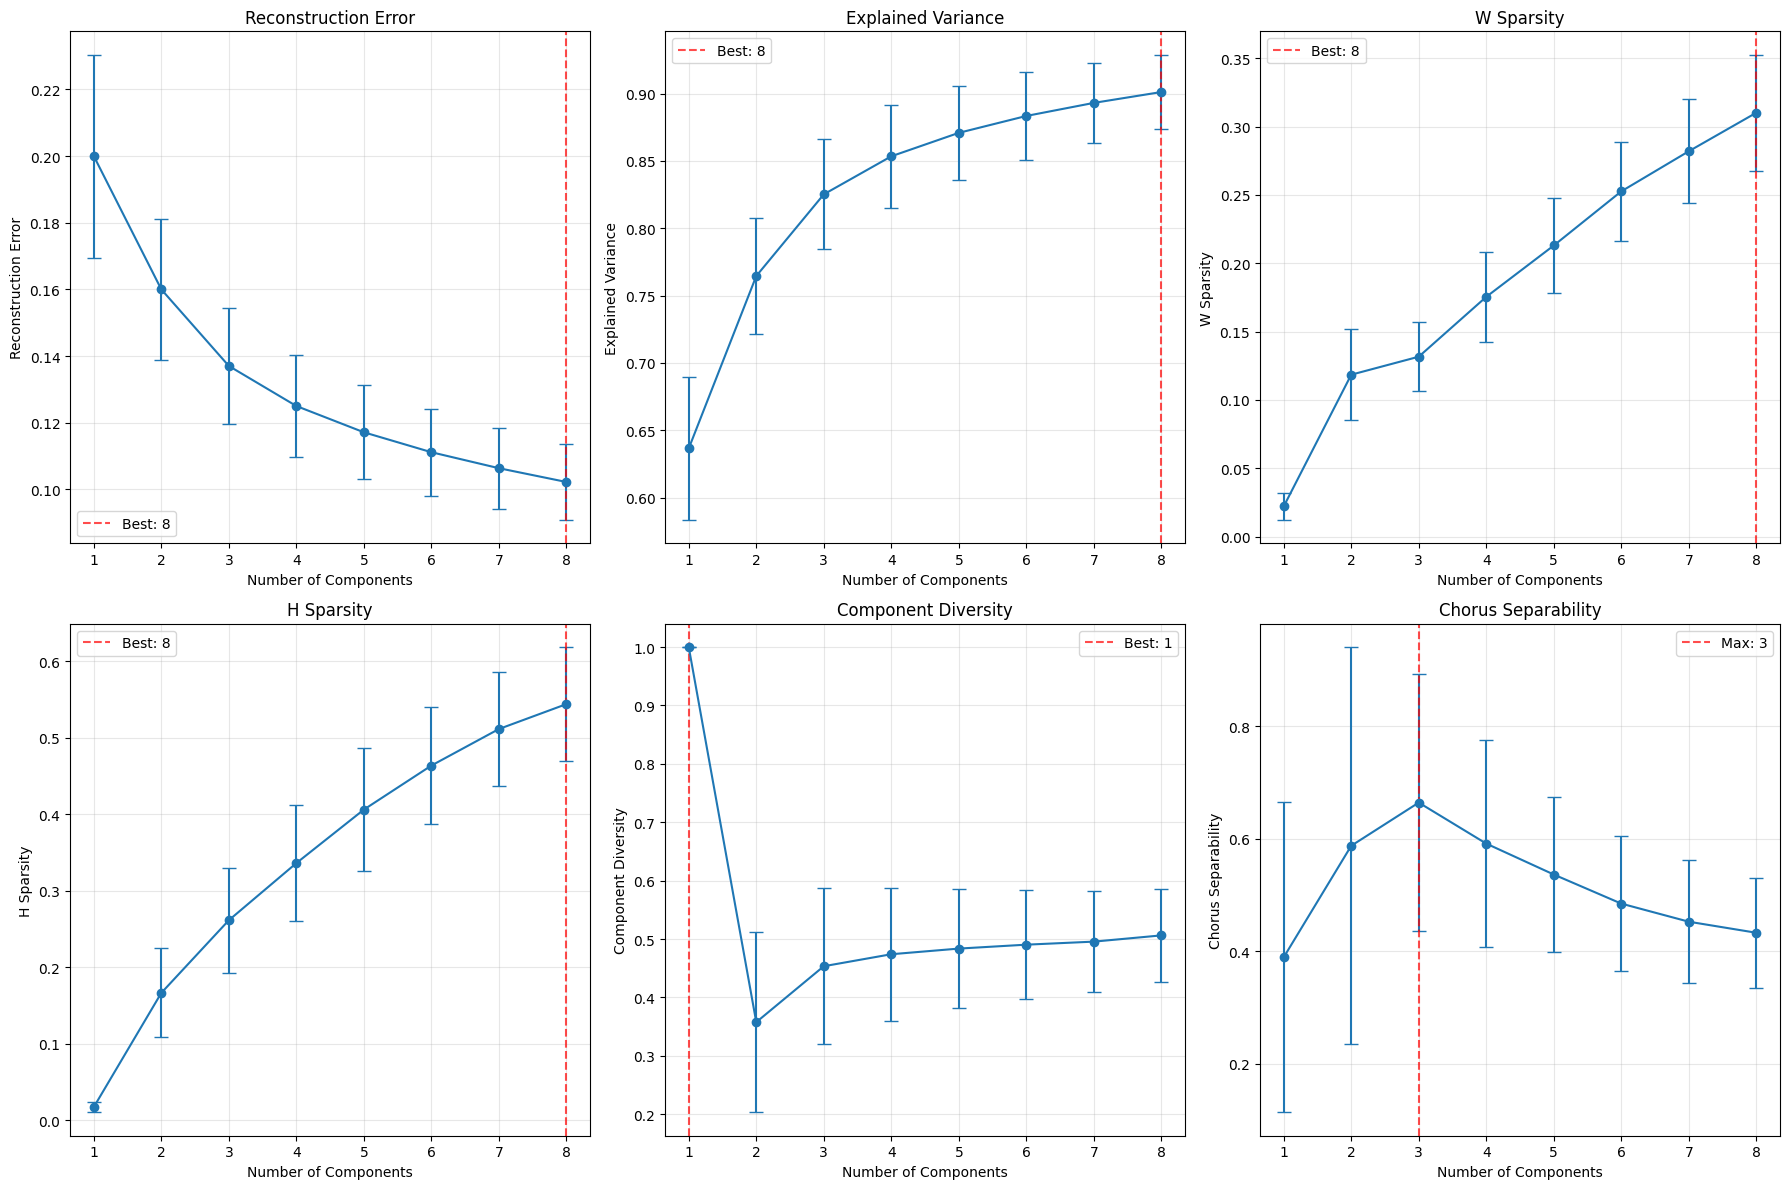


OPTIMAL N_COMPONENTS RECOMMENDATIONS (Log Mel-Spectrograms)
reconstruction_errors    :  8 components (weight: 0.25)
explained_variances      :  8 components (weight: 0.15)
chorus_separabilities    :  3 components (weight: 0.40)
diversities              :  1 components (weight: 0.15)
h_sparsities             :  8 components (weight: 0.05)
----------------------------------------------------------------------
WEIGHTED RECOMMENDATION: 5 components
----------------------------------------------------------------------

CHORUS SEPARABILITY BY N_COMPONENTS:
  1 components: 0.389
  2 components: 0.587
  3 components: 0.664
  4 components: 0.591
  5 components: 0.536
  6 components: 0.485
  7 components: 0.453
  8 components: 0.433

Best chorus separability: 3 components (0.664)

RECOMMENDATIONS FOR LOG MEL-SPECTROGRAMS:
- 3-4 components: Good for simple songs, computational efficiency
- 5-6 components: Balanced performance for most songs
- 7-8 components: Better for complex arrangements, mor

In [6]:
recommendation = run_log_mel_optimization(
    audio_dir="../data/audio/processed",
    labels_dir="../data/labels/spec/v1",
    max_songs=100,
    n_components_range=range(1, 11)
)

In [4]:
class NMFGridSearch:
    """Grid search optimization for NMF parameters"""

    def __init__(self, audio_dir, labels_dir, sr=12000, hop_length=128, n_mels=128, n_fft=2048):
        self.audio_dir = audio_dir
        self.labels_dir = labels_dir
        self.sr = sr
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.results = []
        self.best_params = None
        
    def extract_spectrogram(self, audio_file):
        """Extract log mel-spectrogram"""
        try:
            y, _ = librosa.load(audio_file, sr=self.sr)
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=self.sr, n_fft=self.n_fft, 
                hop_length=self.hop_length, n_mels=self.n_mels, fmax=self.sr//2
            )
            log_mel = librosa.power_to_db(mel_spec, ref=np.max)
            # Normalize for NMF (ensure non-negative)
            normalized = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)
            return (normalized - normalized.min() + 1e-6).T
        except Exception as e:
            print(f"Error processing {audio_file}: {e}")
            return None
    
    def load_labels(self, song_id):
        """Load chorus labels"""
        try:
            filepath = os.path.join(self.labels_dir, f"{song_id}_labels_spec_v1.pkl.gz")
            if os.path.exists(filepath):
                with gzip.open(filepath, 'rb') as f:
                    return pickle.load(f).astype(bool)
            print(f"Label file not found: {song_id}_labels_spec_v1.pkl.gz")
            return None
        except Exception as e:
            print(f"Error loading labels for {song_id}: {e}")
            return None
    
    def compute_separability(self, W, labels):
        """Compute chorus separability"""
        if len(labels) != W.shape[0]:
            ratio = len(labels) / W.shape[0]
            new_labels = np.zeros(W.shape[0], dtype=bool)
            for i in range(W.shape[0]):
                orig_idx = int(i * ratio)
                if orig_idx < len(labels):
                    new_labels[i] = labels[orig_idx]
            labels = new_labels
        
        scores = []
        for comp_idx in range(W.shape[1]):
            activations = W[:, comp_idx]
            if np.sum(labels) == 0 or np.sum(~labels) == 0:
                scores.append(0)
                continue
            
            chorus_mean = np.mean(activations[labels])
            non_chorus_mean = np.mean(activations[~labels])
            std_all = np.std(activations)
            
            if std_all > 0:
                scores.append(abs(chorus_mean - non_chorus_mean) / std_all)
            else:
                scores.append(0)
        
        return np.mean(scores)
    
    def compute_sparsity(self, X):
        """Compute Hoyer sparsity"""
        X_flat = X.flatten()
        n = len(X_flat)
        if n <= 1:
            return 0
        l1_norm = np.sum(np.abs(X_flat))
        l2_norm = np.sqrt(np.sum(X_flat**2))
        if l2_norm == 0:
            return 0
        return (np.sqrt(n) - l1_norm / l2_norm) / (np.sqrt(n) - 1)
    
    def evaluate_params(self, spec, labels, n_components, l1_ratio):
        """Evaluate NMF parameters"""
        try:
            model = NMF(
                n_components=n_components, init='nndsvda', random_state=42,
                max_iter=1000, l1_ratio=l1_ratio, tol=1e-6
            )
            W = model.fit_transform(spec)
            H = model.components_
            
            # Metrics
            X_recon = W @ H
            recon_error = np.linalg.norm(spec - X_recon, 'fro') / np.linalg.norm(spec, 'fro')
            separability = self.compute_separability(W, labels)
            w_sparsity = self.compute_sparsity(W)
            h_sparsity = self.compute_sparsity(H)
            combined = recon_error - 0.5 * separability
            
            return {
                'recon_error': recon_error,
                'separability': separability,
                'combined': combined,
                'w_sparsity': w_sparsity,
                'h_sparsity': h_sparsity,
                'n_iter': model.n_iter_,
                'converged': model.n_iter_ < 1000
            }
        except Exception as e:
            print(f"Error evaluating params: {e}")
            return {
                'recon_error': np.inf, 'separability': 0, 'combined': np.inf,
                'w_sparsity': 0, 'h_sparsity': 0, 'n_iter': 1000, 'converged': False
            }
    
    def load_dataset(self, max_songs=None):
        """Load audio and label data"""
        label_files = [f for f in os.listdir(self.labels_dir) if f.endswith('_labels_spec_v1.pkl.gz')]
        song_ids = [f.replace('_labels_spec_v1.pkl.gz', '') for f in label_files]
        
        if max_songs:
            song_ids = song_ids[:max_songs]
        
        dataset = []
        print(f"Loading {len(song_ids)} songs...")
        
        for song_id in tqdm(song_ids, desc="Loading"):
            # Find audio file
            audio_file = None
            for ext in ['.mp3', '.wav', '.flac']:
                path = os.path.join(self.audio_dir, f"{song_id}{ext}")
                if os.path.exists(path):
                    audio_file = path
                    break
            
            if audio_file is None:
                continue
            
            spec = self.extract_spectrogram(audio_file)
            labels = self.load_labels(song_id)
            
            if spec is not None and labels is not None:
                dataset.append({'song_id': song_id, 'spec': spec, 'labels': labels})
        
        print(f"Loaded {len(dataset)} songs successfully")
        return dataset
    
    def run_search(self, max_songs=None):
        """Run grid search"""
        param_grid = {
            'l1_ratio': [0.0, 0.5, 1.0],
            'n_components': [3, 4, 5, 6, 7, 8, 9, 10]
        }
        
        print(f"Grid search: {len(list(ParameterGrid(param_grid)))} combinations")
        print(f"l1_ratio: {param_grid['l1_ratio']}")
        print(f"n_components: {param_grid['n_components']}")
        
        dataset = self.load_dataset(max_songs)
        self.results = []
        
        for params in tqdm(ParameterGrid(param_grid), desc="Grid Search"):
            song_results = []
            for item in dataset:
                result = self.evaluate_params(
                    item['spec'], item['labels'], 
                    params['n_components'], params['l1_ratio']
                )
                song_results.append(result)
            
            # Average across songs
            avg_metrics = {}
            for key in ['recon_error', 'separability', 'combined', 'w_sparsity', 'h_sparsity', 'n_iter']:
                valid = [r[key] for r in song_results if np.isfinite(r[key])]
                avg_metrics[key] = np.mean(valid) if valid else np.inf
            
            convergence = np.mean([r['converged'] for r in song_results])
            
            self.results.append({
                'params': params.copy(),
                **{f'avg_{k}': v for k, v in avg_metrics.items()},
                'convergence': convergence,
                'n_songs': len([r for r in song_results if np.isfinite(r['combined'])])
            })
        
        # Find best
        valid_results = [r for r in self.results if np.isfinite(r['avg_combined'])]
        if valid_results:
            best = min(valid_results, key=lambda x: x['avg_combined'])
            self.best_params = best['params']
            
            print(f"\nBest parameters: {self.best_params}")
            print(f"Combined score: {best['avg_combined']:.4f}")
            print(f"Reconstruction error: {best['avg_recon_error']:.4f}")
            print(f"Separability: {best['avg_separability']:.4f}")
        
        return self.best_params
    
    def plot_results(self):
        """Plot results with readable colors"""
        if not self.results:
            print("No results to plot")
            return
        
        # Extract data
        data = {}
        for r in self.results:
            if np.isfinite(r['avg_combined']):
                l1 = r['params']['l1_ratio']
                nc = r['params']['n_components']
                if l1 not in data:
                    data[l1] = {}
                data[l1][nc] = r
        
        l1_vals = sorted(data.keys())
        nc_vals = sorted(set().union(*[d.keys() for d in data.values()]))
        
        # Create matrices
        metrics = ['avg_combined', 'avg_recon_error', 'avg_separability', 'avg_w_sparsity']
        titles = ['Combined Score', 'Reconstruction Error', 'Separability', 'W Sparsity']
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.flatten()
        
        for i, (metric, title) in enumerate(zip(metrics, titles)):
            matrix = np.full((len(nc_vals), len(l1_vals)), np.nan)
            
            for j, l1 in enumerate(l1_vals):
                for k, nc in enumerate(nc_vals):
                    if nc in data[l1]:
                        matrix[k, j] = data[l1][nc][metric]
            
            # Plot with better colors
            if metric in ['avg_combined', 'avg_recon_error']:
                cmap = 'RdYlBu_r'  # Red (bad) to Blue (good)
            else:
                cmap = 'RdYlBu'    # Blue (low) to Red (high)
            
            im = axes[i].imshow(matrix, cmap=cmap, aspect='auto')
            axes[i].set_xticks(range(len(l1_vals)))
            axes[i].set_xticklabels([f'{x:.1f}' for x in l1_vals])
            axes[i].set_yticks(range(len(nc_vals)))
            axes[i].set_yticklabels(nc_vals)
            axes[i].set_xlabel('L1 Ratio')
            axes[i].set_ylabel('N Components')
            axes[i].set_title(title)
            
            plt.colorbar(im, ax=axes[i])
            
            # Add text with good contrast
            for k in range(len(nc_vals)):
                for j in range(len(l1_vals)):
                    if not np.isnan(matrix[k, j]):
                        # Use black text for better readability
                        axes[i].text(j, k, f'{matrix[k, j]:.3f}', 
                                   ha="center", va="center", color="black", 
                                   fontsize=8, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    def summary(self):
        """Print detailed summary"""
        if not self.results:
            print("No results available")
            return None
        
        print(f"\n{'='*90}")
        print("GRID SEARCH RESULTS")
        print(f"{'='*90}")
        print(f"{'L1':<4} {'NC':<3} {'Combined':<9} {'Recon':<7} {'Separ':<7} {'WSpar':<7} {'HSpar':<7} {'Iter':<5} {'Conv':<5}")
        print(f"{'-'*90}")
        
        sorted_results = sorted(self.results, key=lambda x: x['avg_combined'])
        
        for r in sorted_results:
            if np.isfinite(r['avg_combined']):
                print(f"{r['params']['l1_ratio']:<4.1f} "
                      f"{r['params']['n_components']:<3} "
                      f"{r['avg_combined']:<9.4f} "
                      f"{r['avg_recon_error']:<7.4f} "
                      f"{r['avg_separability']:<7.4f} "
                      f"{r['avg_w_sparsity']:<7.4f} "
                      f"{r['avg_h_sparsity']:<7.4f} "
                      f"{r['avg_n_iter']:<5.0f} "
                      f"{r['convergence']:<5.1%}")
        
        # Check l1_ratio effects
        print(f"\n{'='*50}")
        print("L1_RATIO EFFECT ANALYSIS")
        print(f"{'='*50}")
        
        for nc in range(2, 11):
            nc_results = [r for r in sorted_results if r['params']['n_components'] == nc]
            if nc_results:
                sparsities = [r['avg_w_sparsity'] for r in nc_results]
                if max(sparsities) - min(sparsities) < 0.001:
                    print(f"NC={nc}: W sparsity barely changes ({min(sparsities):.4f}-{max(sparsities):.4f}) ⚠️")
                else:
                    print(f"NC={nc}: W sparsity varies ({min(sparsities):.4f}-{max(sparsities):.4f}) ✓")
        
        return sorted_results


In [ ]:
def grid_search(audio_dir, labels_dir, max_songs=None):
    """
    Run NMF grid search optimization
    
    Args:
        audio_dir: Audio files directory
        labels_dir: Labels directory  
        max_songs: Max songs to use (None for all)
    
    Returns:
        best_params: Optimal parameters
        optimizer: NMFGridSearch object
    """
    print("NMF Grid Search Optimization")
    print("l1_ratio: [0.0, 0.5, 1.0]")
    print("n_components: [3, 4, 5, 6, 7, 8, 9, 10]")
    
    optimizer = NMFGridSearch(audio_dir, labels_dir)
    best_params = optimizer.run_search(max_songs)
    optimizer.summary()
    optimizer.plot_results()
    
    return best_params, optimizer

audio_dir = "../data/audio/processed"
labels_dir = "../data/labels/spec/v1"
grid_search(audio_dir, labels_dir, max_songs=100)


NMF Grid Search Optimization
l1_ratio: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_components: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Grid search: 54 combinations
l1_ratio: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_components: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Loading 100 songs...


Loading:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded 99 songs successfully


Grid Search:   0%|          | 0/54 [00:00<?, ?it/s]

KeyboardInterrupt: 